In [1]:
# Sprint 3: Data Cleaning

## Project
InsightForge – Retail Intelligence Platform

## Objective
Clean and validate the Olist E-commerce dataset before analysis and SQL loading.

## Author
Gurleen Kaur Sawhney

## Date
August 2026

SyntaxError: invalid character '–' (U+2013) (143274039.py, line 4)

In [2]:
## Goals

- Identify missing values
- Handle duplicates
- Validate data types
- Detect invalid values
- Create cleaned datasets
- Save cleaned data for SQL and Power BI

SyntaxError: invalid syntax (1173769619.py, line 3)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
from pathlib import Path

DATA_PATH = Path("../data/raw")

orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

In [5]:
# Store all datasets in a dictionary

datasets = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

In [6]:
quality_report = []

for name, df in datasets.items():

    report = {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    }

    quality_report.append(report)

quality_report = pd.DataFrame(quality_report)

quality_report

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,orders,99441,8,4908,0
1,customers,99441,5,0,0
2,order_items,112650,7,0,0
3,products,32951,9,2448,0
4,payments,103886,5,0,0
5,reviews,99224,7,145903,0
6,sellers,3095,4,0,0
7,geolocation,1000163,5,0,261831
8,category_translation,71,2,0,0


In [8]:
# Missing values by column

for name, df in datasets.items():

    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if missing.empty:
        print("✅ No missing values found.")

    else:
        print(missing)

    print()

DATASET: orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

DATASET: customers
✅ No missing values found.

DATASET: order_items
✅ No missing values found.

DATASET: products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

DATASET: payments
✅ No missing values found.

DATASET: reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

DATASET: sellers
✅ No missing values found.

DATASET: geolocation
✅ No missing values found.

DATASET: category_translation
✅ No missing values found.



In [9]:
# Display data types for every dataset

for name, df in datasets.items():

    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    print(df.dtypes)

    print()

DATASET: orders
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

DATASET: customers
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

DATASET: order_items
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

DATASET: products
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_

In [10]:
# Date columns in the orders table

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [11]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [12]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [13]:
orders["order_purchase_timestamp"].min()

Timestamp('2016-09-04 21:15:19')

In [14]:
orders["order_purchase_timestamp"].max()

Timestamp('2018-10-17 17:30:18')

In [15]:
# Check for invalid prices

invalid_prices = order_items[order_items["price"] < 0]

print(f"Invalid price records: {len(invalid_prices)}")

invalid_prices.head()

Invalid price records: 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [16]:
zero_prices = order_items[order_items["price"] == 0]

print(f"Zero-priced records: {len(zero_prices)}")

zero_prices.head()

Zero-priced records: 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [17]:
invalid_freight = order_items[order_items["freight_value"] < 0]

print(f"Invalid freight records: {len(invalid_freight)}")

invalid_freight.head()

Invalid freight records: 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [18]:
invalid_reviews = reviews[
    (reviews["review_score"] < 1) |
    (reviews["review_score"] > 5)
]

print(f"Invalid review scores: {len(invalid_reviews)}")

invalid_reviews.head()

Invalid review scores: 0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [19]:
invalid_delivery = orders[
    orders["order_delivered_customer_date"]
    < orders["order_purchase_timestamp"]
]

print(f"Impossible deliveries: {len(invalid_delivery)}")

invalid_delivery.head()

Impossible deliveries: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days


In [20]:
# Create Year-Month column

orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [21]:
monthly_orders = (
    orders
    .groupby("order_month")
    .size()
    .reset_index(name="Number_of_Orders")
)

monthly_orders.head()

,order_month,Number_of_Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [22]:
monthly_orders["order_month"] = (
    monthly_orders["order_month"]
    .astype(str)
)

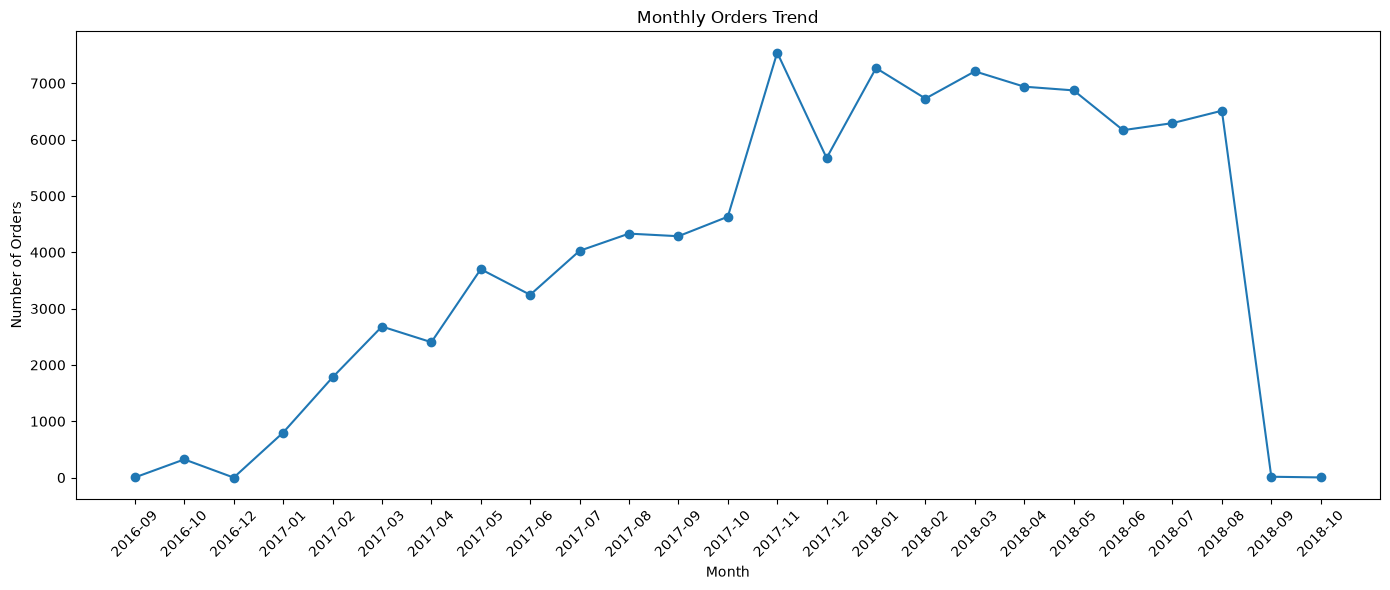

In [25]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["order_month"],
    monthly_orders["Number_of_Orders"],
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [28]:
# Calculate revenue for each order

orders_with_revenue = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_revenue")
)

orders_with_revenue = orders.merge(
    orders_with_revenue,
    on="order_id",
    how="left"
)

orders_with_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,order_month,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,2018-02,19.90


In [29]:
from pathlib import Path

CLEAN_PATH = Path("../data/cleaned")

CLEAN_PATH.mkdir(parents=True, exist_ok=True)

In [30]:
orders.to_csv(CLEAN_PATH / "orders_cleaned.csv", index=False)

customers.to_csv(CLEAN_PATH / "customers_cleaned.csv", index=False)

order_items.to_csv(CLEAN_PATH / "order_items_cleaned.csv", index=False)

products.to_csv(CLEAN_PATH / "products_cleaned.csv", index=False)

payments.to_csv(CLEAN_PATH / "payments_cleaned.csv", index=False)

reviews.to_csv(CLEAN_PATH / "reviews_cleaned.csv", index=False)

sellers.to_csv(CLEAN_PATH / "sellers_cleaned.csv", index=False)

geolocation.to_csv(CLEAN_PATH / "geolocation_cleaned.csv", index=False)

category_translation.to_csv(
    CLEAN_PATH / "category_translation_cleaned.csv",
    index=False
)

In [31]:
import os

os.listdir("../data/cleaned")

['customers_cleaned.csv',
 'category_translation_cleaned.csv',
 'sellers_cleaned.csv',
 'products_cleaned.csv',
 'geolocation_cleaned.csv',
 'order_items_cleaned.csv',
 'orders_cleaned.csv',
 'payments_cleaned.csv',
 'reviews_cleaned.csv']